# Inverted Pendulum Example

This is an example file that shows how to experiment and create stabilizing controllers for the inverted pendulum
dynamical system. This program is broken into 3 parts:

1) Initializing the pendulum at equilibrium with a controller that outputs arbitrarily small but constant disturbance.
   Here, the user should be able to follow the trajectory plot and use their intuition to see that the pendulum is
   falling away from equilibrium and swinging.

2) Initializing the pendulum slightly away from the equilibrium but using an LQR controller to stabilize it back towards
   the equilibrium. The LQR solution returns a controller in state feedback form as well as a
   quadratic Lyapunov function. For state samples near the equilibrium, it should be visually clear that this Lyapunov
   function fulfills the stability conditions.

3) Initializing the pendulum slightly away from the equilibrium but using a neural network (NN) controller in feedback
   configuration. The NN is fit onto the previous LQR controller before being implemented. Notice that this controller is stabilizing, but it does not get our system exactly to equilibrium

# Dynamics

The dynamics can be described as follows:
$$
\begin{bmatrix}\dot{\theta} \\ \ddot{\theta}\end{bmatrix}
=
\begin{bmatrix}
\dot{\theta} \\ \frac{g}{l}\sin(\theta) - \frac{b\dot{\theta}}{ml^2} + \frac{u}{ml^2}
\end{bmatrix}
$$
where $g$ is gravity, $l$ is the length of the pendulum, $m$ is its mass, $b$ is the damping factor, and $u$ is the control input. The states themselves are $\begin{bmatrix}\theta & \dot{\theta} & \ddot{\theta}\end{bmatrix}$ which represent the pendulum's angular orientation, velocity, and acceleration, respectively.

In [1]:
# imports
import scipy
import numpy as np
from numpy import ndarray
import torch
import torch.nn as nn
from torch import Tensor
from torch.utils.data import DataLoader
from typing import Union, Tuple, Optional, Callable
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from SimpleExamples.zubov.utils import get_lr_scheduler

In [2]:
# additional helpers
# torch default options
set_t = {
    "dtype": torch.float32,
    "device": torch.device("cuda"),  # set to cpu if you don't have a graphics card
}
save_path = "inverted_pendulum_plots/"
show = True   # True if we want to display the plots in the notebook
save = False  # True if we want to save the plots as well as .png files

to_numpy = lambda x : x.detach().cpu().numpy() if isinstance(x, Tensor) else x  # converts Tensor to Numpy array

In [3]:
# Our dynamic parameters spelled out for clearer context
dynamic_parameters = {
    "mass": 0.15,
    "length": 0.5,
    "gravity": 9.81,
    "damping": 0.1,
    "time_step": 0.01,
    "time_horizon": 10
}

In [4]:
# basic neural network architecture
class SimpleNNController(nn.Module):
    def __init__(self, in_dim: int, out_dim: int,
                 out_lb: Optional[Union[Tensor, float]] = None,
                 out_ub: Optional[Union[Tensor, float]] = None):

        super(SimpleNNController, self).__init__()

        layers = [
            nn.Linear(in_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, out_dim),
        ]
        if out_lb is not None and out_ub is not None:
            self.output_constraint = lambda t : torch.clip(t, min=out_lb, max=out_ub)
        else:
            self.output_constraint = lambda t : t

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        y = self.model(x)
        y_clipped = self.output_constraint(y)
        return y_clipped

In [5]:
# Pendulum Dyanmics
class PendulumDynamics:
    """
    The inverted pendulum, with the upright equilibrium as the state origin.
    """

    def __init__(self, m: float = 1, l: float = 1, beta: float = 1, g: float = 9.81, dt: float = 0.05):
        self.nx = 2
        self.nq = self.nx // 2
        self.nu = 1
        self.ny = 1
        self.dt = dt
        self.m = m  # Mass
        self.l = l  # Length
        self.g = g  # Gravity
        self.beta = beta  # Damping
        self.inertia = self.m * self.l**2

    def forward_trajectory(self, x: Tensor, u: Callable, num_iters: int = 1) -> Tensor:
        """
        Runs a trajectory given an initial state and a state feedback controller.
        The trajectory does not include the initial state.
        x:          state (batch, 2);
        u:          State-feedback controller
        :returns    Trajectory (batch, num_iters, 2)
        """
        traj = torch.empty((x.shape[0], num_iters, self.nx)).to(x)
        curr_x = x
        for i in range(num_iters):
            curr_u = u(curr_x)
            xdot = self.fx(curr_x, curr_u)
            new_x = curr_x + self.dt * xdot
            traj[:, i, :] = new_x
            curr_x = new_x

        return traj

    def forward(self, x: Tensor, u: Callable) -> Tensor:
        """
        Runs a single trajectory step given an initial state and a state feedback controller.
        x:          state (batch, 2);
        u:          State-feedback controller
        :returns    Trajectory (batch, 2)
        """
        curr_u = u(x)
        xdot = self.fx(x, curr_u)
        new_x = x + self.dt * xdot
        return new_x

    def fx(self, x: Tensor, u: Tensor) -> Tensor:
        """
        Computes xdot given the current state and input.
        :param x:   Current state (batch, 2)
        :param u:   Current control input (batch, 1)
        :return:    xdot (batch, 2)
        """
        theta, theta_dot = x[:, 0], x[:, 1]
        theta = theta.unsqueeze(-1)
        theta_dot = theta_dot.unsqueeze(-1)
        # Dynamics according to http://underactuated.mit.edu/pend.html
        ml2 = self.m * self.l * self.l
        d_theta = theta_dot
        d_theta_dot = (
            (-self.beta / ml2) * theta_dot
            + (self.g / self.l) * torch.sin(theta)
            + u / ml2
        )
        xdot = torch.cat((d_theta, d_theta_dot), dim=1)
        return xdot

    def __call__(self, x: Tensor, u: Callable, num_iters: int = 1) -> Tensor:
        return self.forward(x, u, num_iters)

    def linearized_dynamics(self, x: Tensor):
        # FIXME:
        #   This linearization does not work as expected. Perhaps it
        #   was not written down correctly.
        device = x.device
        batch_size = x.shape[0]
        A = torch.zeros((batch_size, self.nx, self.nx))
        B = torch.zeros((batch_size, self.nx, self.nu))
        A[:, 0, 1] = 1
        A[:, 1, 0] = self.g / self.l * torch.sin(x[:, 0])
        A[:, 1, 1] = -self.beta / (self.inertia)
        B[:, 1, 0] = 1 / self.inertia
        return A.to(device), B.to(device)

    def linearized_dynamics_grad(self) -> Tuple[Tensor, Tensor]:
        """
        Uses PyTorch autograd to linearize the pendulum about the equilibrium point.
        This is one alternative to exactly computing the linearization.
        :return:
        """
        x = self.x_equilibrium.unsqueeze(0)
        x.requires_grad = True
        u = self.u_equilibrium.unsqueeze(0)
        u.requires_grad = True
        xdot = pendulum_continuous.fx(x, u)
        qddot = xdot[:, self.nq:]
        A = torch.empty((2, 2))
        B = torch.empty((2, 1))
        A[0, 0] = 0
        A[0, 1] = 1
        B[0, 0] = 0
        A[1], B[1] = torch.autograd.grad(qddot[0, 0], [x, u])
        return A, B

    @property
    def x_equilibrium(self) -> Tensor:
        return torch.zeros((2,))

    @property
    def u_equilibrium(self) -> Tensor:
        return torch.zeros((1,))


In [6]:
def plot_states(
        t: Union[Tensor, ndarray],
        x: [Tensor, ndarray],
        title: str,
        y_labels: Optional[list[str]] = None,
        equilibrium_points: Optional[Union[Tensor, ndarray]] = None,
        show: bool = False,
        save_name: Optional[str] = None,
        max_cols: int = 4,
        max_subplots: int = 12
):
    """
    Plots the state trajectories for some dynamical system.
    :param t:               Array of timesteps
    :param x:               State trajectories, 1st dim is time, 2nd dim are states
    :param title:           The suptitle of the plot
    :param y_labels:        Descriptors for the states
    :param show:            True if the plot should be shown
    :param save_name:       If not None, saves the plot with the specified file name
    :param max_cols:        Maximum number of columns in the plot
    :param max_subplots:    Maximum number of subplots to handle
    :return:
    """

    assert len(x.shape) == 2, "States should be two dimensional arrays"

    # Convert to numpy arrays
    if isinstance(t, Tensor):
        t = to_numpy(t)
    if isinstance(x, Tensor):
        x = to_numpy(x)
    if equilibrium_points is not None and isinstance(equilibrium_points, Tensor):
        equilibrium_points = to_numpy(equilibrium_points)

    # handles subplot formatting for arbitrary number of state dimensions
    n_dim = x.shape[1]
    fig = plt.figure(figsize=(12, 8))
    fig.suptitle(title)
    cols = max_cols
    plot_batches = min(n_dim, max_subplots)
    if plot_batches <= cols:
        cols = plot_batches
        rows = 1
    else:
        rows = ceil(plot_batches / cols)
    # subplot offset where first digit are total rows, second digit are total columns, third digit is current subplot
    base_subplot = rows * 100 + cols * 10
    axes = [(i, fig.add_subplot(base_subplot + i + 1)) for i in range(n_dim)]

    for i, ax in axes:
        ax.plot(t, x[:, i])
        ax.set_xlabel("Time")
        if y_labels is not None:
            ax.set_ylabel(y_labels[i])
        else:
            ax.set_ylabel(f"State {i}")
        if equilibrium_points is not None:
            ax.axhline(y=equilibrium_points[i], color='r', linestyle='--', linewidth=1, label='Equilibrium')
            ax.legend()
        ax.grid()

    plt.tight_layout()  # resize the subplots

    if save_name is not None:
        fig.savefig(save_path + save_name)

    if show:
        plt.show()
    else:
        plt.close()

    return

In [7]:
def compute_lqr(pendulum_continuous: PendulumDynamics):
    """
    Computes the LQR controller about some equilibrium point.
    The solution entails a controller in linear feedback form u=Kx
    as well a Lyapunov function in quadratic form V=x^TSx.
    :param pendulum_continuous: Continuous pendulum model
    :return:                    Controller, Lyapunov function
    """
    # A, B = linearize_pendulum(pendulum_continuous)
    # A, B = pendulum_continuous.linearized_dynamics(pendulum_continuous.x_equilibrium.unsqueeze(0))
    A, B = pendulum_continuous.linearized_dynamics_grad()
    A_np, B_np = [to_numpy(t) for t in [A, B]]
    # A_np, B_np = A.detach().numpy(), B.detach().numpy()
    Q = np.eye(2)
    R = np.eye(1) * 100
    S = scipy.linalg.solve_continuous_are(A_np, B_np, Q, R)
    K = np.linalg.solve(R, B_np.T @ S)
    return K, S

def approximate(
        system: nn.Module,
        system_input: Tensor,
        target: Tensor,
        lr: float,
        max_iter: int,
        verbose:bool = False
):
    """
    Fits a neural network controller to an LQR controller
    :param system:          The NN controller to train
    :param system_input:    State samples
    :param target:          Target control for each state sample
    :param lr:              Learning rate
    :param max_iter:        Number of training iterations
    :return:
    """
    optimizer = torch.optim.Adam(system.parameters(), lr=lr)
    losses = np.zeros(max_iter)
    for i in range(max_iter):
        optimizer.zero_grad()
        output = torch.nn.MSELoss()(system.forward(system_input), target)
        if verbose: print(f"iter {i}, loss {output.item()}")
        losses[i] = output.item()
        output.backward()
        optimizer.step()

    return losses

In [8]:
# get dynamic parameters
m = dynamic_parameters["mass"]
l = dynamic_parameters["length"]
g = dynamic_parameters["gravity"]
beta = dynamic_parameters["damping"]
dt = dynamic_parameters["time_step"]
T = dynamic_parameters["time_horizon"]

# initialize the dynamical system
pendulum_continuous = PendulumDynamics(m=m, l=l, beta=beta, dt=dt)

n_dim = pendulum_continuous.nx  # state dimension
m_dim = pendulum_continuous.nu  # controller dimension

time_steps = torch.arange(0, T, dt)  # time steps
n_time_steps = len(time_steps)

## 1.) Constant Disturbance
Here, we illustrate how the system evolves where the controller simply functions as an input to the system that introduces constant disturbance.


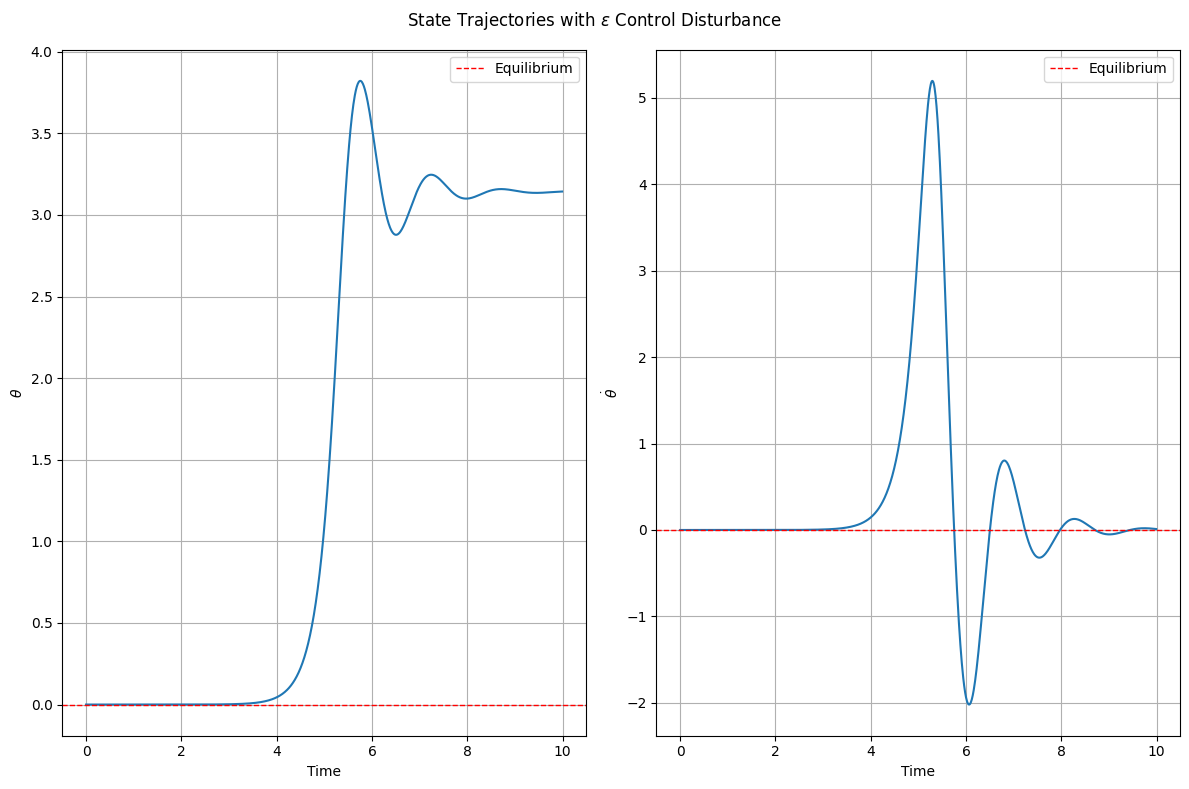

In [9]:
init_state = torch.zeros((1, n_dim), **set_t)  # initial state at equilibrium
# feedback controller simply returns ε disturbance into the system
u = lambda x : torch.full((x.shape[0], m_dim), torch.finfo(x.dtype).eps,).to(x)

# simulate dynamics
traj = pendulum_continuous.forward_trajectory(init_state, u, num_iters=n_time_steps - 1)
traj = torch.cat((init_state, traj.squeeze(0)), dim=0)

# plot results
plot_states(time_steps, traj, r"State Trajectories with $\epsilon$ Control Disturbance",
            [r"$\theta$", r"$\dot{\theta}$"], pendulum_continuous.x_equilibrium,
            show, "const_perturbed_control.png" if save else None)

## 2.) LQR Stabilization
We illustrate how the system may be stabilized near the equilibrium point via a controller designed through LQR.

K shape: torch.Size([1, 2]), V shape: torch.Size([101, 1])


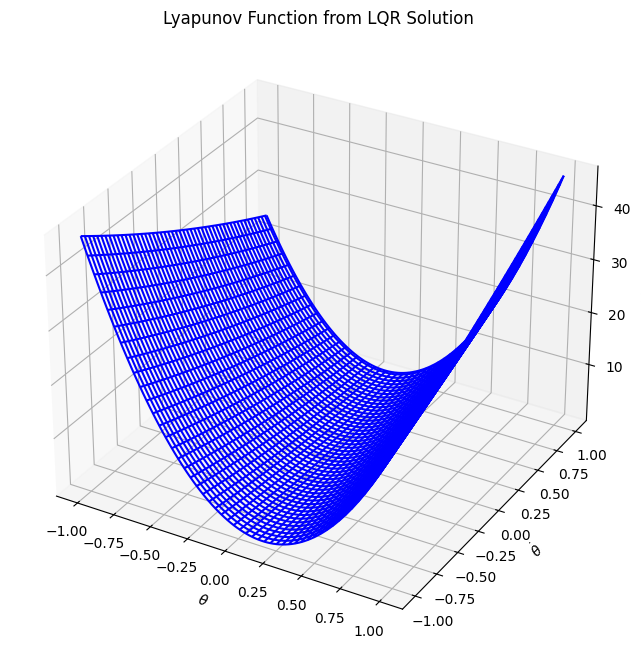

Using controller constraint: |0.24525|


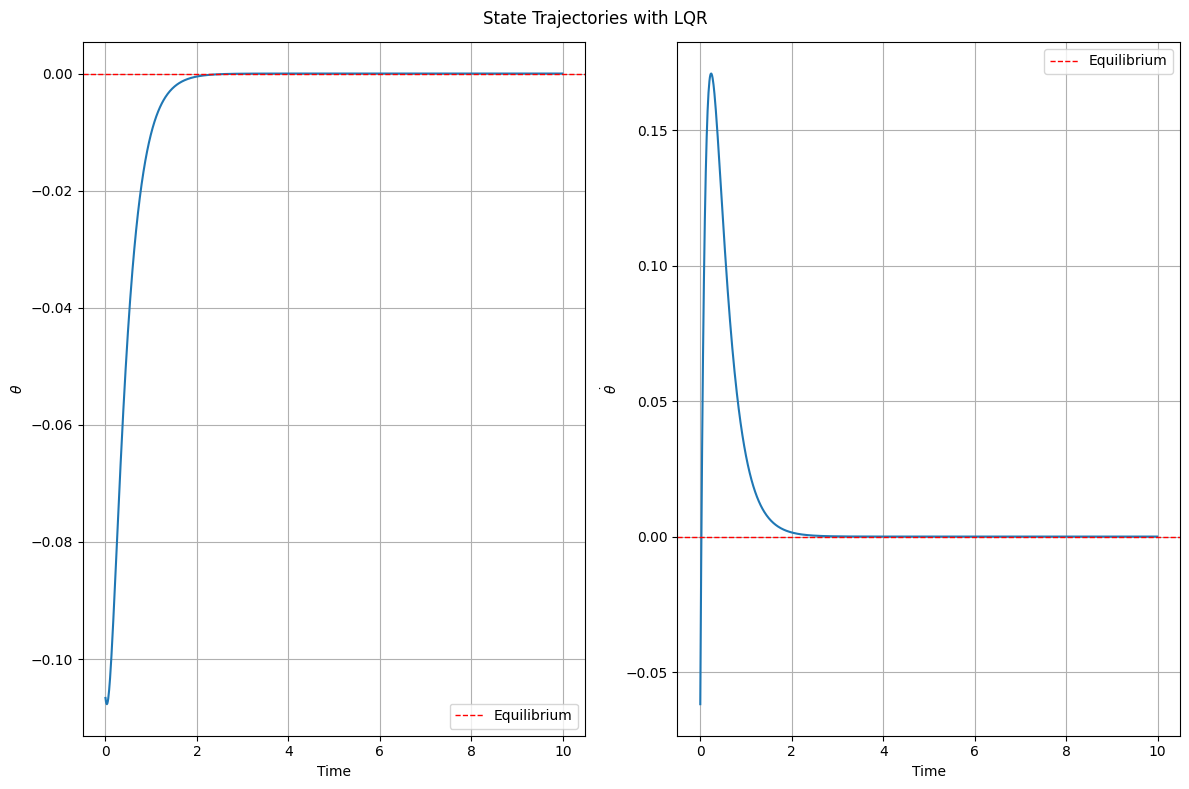

In [10]:
K, S = compute_lqr(pendulum_continuous)
# convert to Tensors
K = torch.from_numpy(K).to(**set_t)  # linear feedback controller
S = torch.from_numpy(S).to(**set_t)  # quadratic Lyapunov function
x = (torch.rand((100, 2), **set_t) - 0.5) * 2  # create a bunch of state samples near the origin to stabilize
x = torch.cat([x, torch.zeros((1, 2), **set_t)], dim=0)  # make sure to include the equilibrium
V = torch.sum(x * (x @ S), axis=1, keepdim=True)
print(f"K shape: {K.shape}, V shape: {V.shape}")

# plot the output of the Lyapunov function for these samples
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
x_np = np.linspace(-1, 1, 100)
y_np = np.linspace(-1, 1, 100)
x_np, y_np = np.meshgrid(x_np, y_np)
lqr_lya = lambda x: np.sum(x * (x @ to_numpy(S)), axis=1)  # applies Lyapunov function to state inputs
V_np = lqr_lya(np.concatenate([x_np.ravel().reshape(-1, 1), y_np.ravel().reshape(-1, 1)], axis=1))
V_np = V_np.reshape(x_np.shape)
ax.plot_wireframe(x_np, y_np, V_np, color='b')
ax.set_title("Lyapunov Function from LQR Solution")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\dot{\theta}$")
ax.set_zlabel(r"$V(x)$")
if save: plt.savefig(save_path + "lqr_quadratic_lyapunov_function.png")
plt.show() if show else plt.close()

# now initialize the states with some disturbance
std = torch.tensor([torch.pi/4, torch.pi/4], **set_t)
noise = torch.normal(pendulum_continuous.x_equilibrium.to(std), std)
init_state = noise.unsqueeze(0)

# LQR feedback controller (with constraints)
mgl_3 = (m*g*l) / 3
out_lb = -mgl_3
out_ub = mgl_3
print(f"Using controller constraint: |{mgl_3}|")
def lqr_controller(x: Tensor) -> Tensor:
    # x shape (batches, n_dim)
    x_bar = x - pendulum_continuous.x_equilibrium.reshape(1, -1).to(x)
    control_input = torch.einsum("mn,bn->bm", -K.to(x_bar), x_bar)

    if out_lb is not None and out_ub is not None:
        control_input = torch.clip(control_input, out_lb, out_ub)

    return control_input

# simulate dynamics
traj = pendulum_continuous.forward_trajectory(init_state, lqr_controller, num_iters=n_time_steps - 1)
traj = torch.cat((init_state, traj.squeeze(0)), dim=0)

# plot results
plot_states(time_steps, traj, r"State Trajectories with LQR",
            [r"$\theta$", r"$\dot{\theta}$"], pendulum_continuous.x_equilibrium,
            show, "lqr_control.png" if save else None)

## 3.) NN Control
We illustrate how a NN can be used to learn the LQR controller and replace the LQR controller itself.

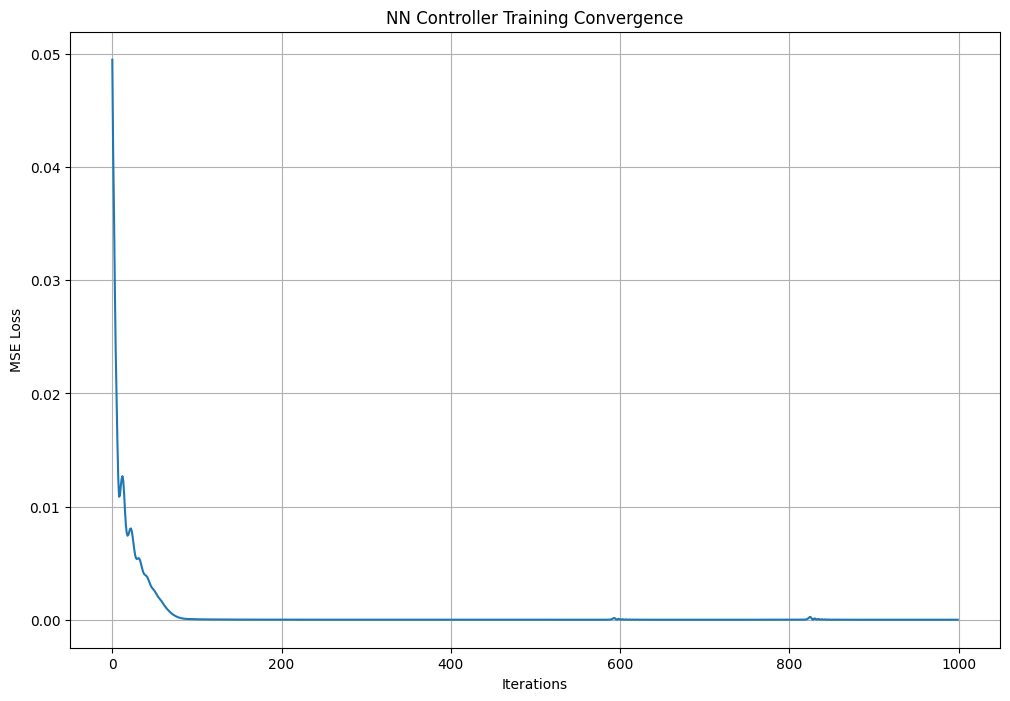

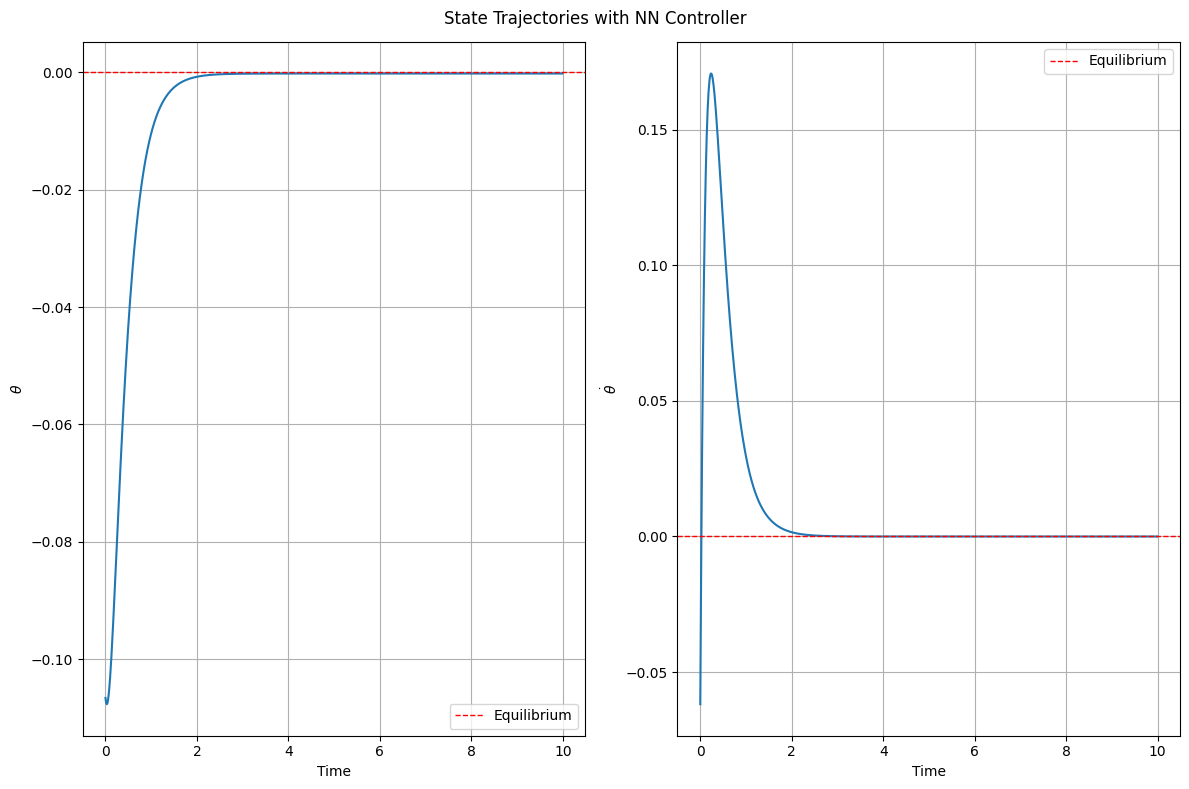

In [11]:
x = (torch.rand((100000, 2), **set_t) - 0.5) * 2  # create a bunch of state samples near the origin to stabilize
x = torch.cat([x, torch.zeros((1, 2), **set_t)], dim=0)  # make sure to include the equilibrium
# lqr_samples = torch.einsum('ij,bj->bi', -K, (x - pendulum_continuous.x_equilibrium.unsqueeze(0)))
lqr_samples = lqr_controller(x)
# lqr_samples = x @ K.permute(1, 0)  # get the control feedback for these states
nn_controller = SimpleNNController(n_dim, m_dim, out_lb=-1., out_ub=1.).to(device=set_t["device"])  # initialize a simple NN controller
losses = approximate(nn_controller, x, lqr_samples, lr=0.01, max_iter=1000)  # fit the NN to the LQR controller

# plot the training loss
plt.figure(figsize=(12, 8))
plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("NN Controller Training Convergence")
plt.grid()
if save: plt.savefig(save_path + "nn_controller_loss.png")
plt.show() if show else plt.close()

# simulate dynamics, reusing the same initial state from previous section
traj = pendulum_continuous.forward_trajectory(init_state, nn_controller, n_time_steps - 1)
traj = torch.cat((init_state, traj.squeeze(0)), dim=0)

# plot results
plot_states(time_steps, traj, r"State Trajectories with NN Controller",
            [r"$\theta$", r"$\dot{\theta}$"], pendulum_continuous.x_equilibrium,
            show, "nn_control.png" if save else None)

# Zubov's PDE

In this section, we will now experiment with using a NN to learn a maximal Lyapunov function on the inverted pendulum problem with an LQR controller.

In [12]:
# imports related to Zubov PDE training
from SimpleExamples.zubov.architecture import ZubovNetwork, GeneralNeuralNetwork #,ZubovNetworkWithSiren
from SimpleExamples.zubov.dataset import *
from tqdm import tqdm

# Training the Zubov Function with an LQR Controller
--batch_size
310000
--n_epochs
50000
--siren_lr
0.00005
--final_siren_lr
0.000005
--latent_lr
0.001
--final_latent_lr
0.00001
--scheduler_type
linear
--clip_gradient_norm
1.0
--n_layers
5
--layer_width
64
--siren_latent_dim
64

In [13]:
# initialize neural networks
zubov_nn_args = {
    # structure arguments
    "width": 64,
    "n_layers": 3,
    "input_dim": pendulum_continuous.nx,
    "output_dim": 1,
    "act": "tanh",
    "final_act": "sigmoid",
    # training arguments
    "optimizer": torch.optim.Adam,
    "optimizer_parameters": {
        "lr": 1e-3,
        "weight_decay": 1e-5,
    },
    "learning_rate_scheduler": "step",
    "learning_rate_parameters": {
        "step_size": 25,
        "gamma": 0.1,
        "final_lrate": 8e-4,
    },
}
zubov_nn = GeneralNeuralNetwork(**zubov_nn_args)

train_controller = False
if train_controller:
    controller_nn_args = {

    }
    zubov_controller = GeneralNeuralNetwork(**controller_nn_args).to(**set_t)
else:
    zubov_controller = lqr_controller

In [14]:
# initialize the networks
common_args = {
    "dynamical_system": pendulum_continuous,
    "zubov_fn": zubov_nn.to(**set_t),
    "controller": zubov_controller,
    # "lb": -4*torch.ones_like(pendulum_continuous.x_equilibrium).cpu(),
    "lb": torch.tensor([-2., -4.], dtype=set_t["dtype"], device=torch.device("cpu")),
    # "ub": 4*torch.ones_like(pendulum_continuous.x_equilibrium).cpu(),
    "ub": torch.tensor([2., 4.], dtype=set_t["dtype"], device=torch.device("cpu")),
    "num_epochs": 500,
}
zubov_args = {
    "train_controller": train_controller,
    "alpha": 0.05,
    "barrier_scale": 1.,
    "max_steps": int(5e3),
    "c1": 5e1, "c2": 3e3, "c3": 1e2, "c4": 1e1,
}
zubov_args.update(common_args)
# zubov_siren_args = {
#     "alpha": 0.05,
#     "hidden_features": 64,
#     "hidden_layers": 5,
#     "latent_dim": 64,
#     "output_dim": 1,
#     "siren_lrate": 0.00005,
#     "latent_lrate": 0.001,
#     "horizon": 10,
#     "final_latent_lrate": 0.00001,
#     "scheduler_type": "linear",
#     "clip_gradient_norm": 1.0,
# }
# zubov_siren_args.update(common_args)

zubov_network = ZubovNetwork(**zubov_args)
# zubov_siren_network = ZubovNetworkWithSiren(**zubov_siren_args)

In [15]:
# initialize the training dataset
batch_size = 2048
use_advance_trajectories = True
adv_traj_dataset = (not train_controller and use_advance_trajectories)
dataset_args = {
    "n_samples": 100_000,
    "lb": common_args["lb"],
    "ub": common_args["ub"],
    "verbose": True, # prints more information when creating the datasets
}
if adv_traj_dataset:
    extra_dataset_args = {
        "dynamical_system": pendulum_continuous,
        "controller_fn": zubov_controller,
        "max_steps": zubov_args["max_steps"],
        "gpu_frac": 0.8,
        "device": set_t["device"],
    }
    dataset_args.update(extra_dataset_args)
# Get the dataset and dataset loader.
# These may be slightly different depending on if the controller is being trained or not.
zubov_dataset, train_loader = get_dataset(advance_trajectories=adv_traj_dataset, batch_size=batch_size,
                                          **dataset_args)

n_samples = 100000
lb shape = torch.Size([1, 2]), ub shape = torch.Size([1, 2])
box_range shape = torch.Size([1, 2])
input_dim = 2
device_id = 0
total_memory_bytes = 6117916672
total_available_bytes = 4894333337
traj_memory_bytes = 4000000000
traj_batches = 1
traj_step_size = 100000


In [19]:
def train_zubov_framework(net: ZubovNetwork, zubov_dataset: Dataset, train_loader: DataLoader, epochs: int, fold: int = 1,
                          stop_barrier_iter: int = int(1e8),
                          network_name: str = 'Zubov Network', visualize: bool = True) -> ZubovNetwork:
    # run the training loop
    # for net, sup in zip((zubov_network, zubov_siren_network), ("Zubov Network", "Zubov SIREN Network")):
    # for net, sup in zip((zubov_network,), ("Zubov Network",)):
    print(f"Beginning training of {network_name}...")
    net.use_barrier = True
    all_epoch_loss, all_loss_z, all_loss_r, all_loss_p, all_loss_b, all_loss_c = [], [], [], [], [], []
    epoch_progress_bar = tqdm(range(epochs), desc="Epochs", leave=True)
    for i in range(epochs):
        if i == stop_barrier_iter:
            net.use_barrier = False

        epoch_loss, loss_z, loss_r, loss_p, loss_b, loss_c = [0.0] * 6
        for _ in range(fold):
            for batch in train_loader:

                batch_x = batch.get("batch_x")
                batch_traj = batch.get("batch_traj", None)

                # (1, batch, nx) -> (batch, nx)
                batch_x = batch_x.reshape(batch_size, pendulum_continuous.nx).to(**set_t)
                batch_traj = batch_traj.to(**set_t) if isinstance(batch_traj, Tensor) else batch_traj

                # step network parameters
                curr_loss, curr_z, curr_r, curr_p, curr_b, curr_c = net.step(batch_x, batch_traj)

                # update epoch losses
                epoch_loss += curr_loss
                loss_z += curr_z
                loss_r += curr_r
                loss_p += curr_p
                loss_b += curr_b
                loss_c += curr_c

        # make sure to discard the previous batch in order to free up gpu
        # memory before generating a new set of samples
        batch_x = None
        batch_traj = None
        train_loader.dataset.reset_samples()

        # step the schedulers
        current_siren_lr, current_latent_lr = net.scheduler_step()
        # normalize the losses
        train_loader_len = len(train_loader) * fold
        epoch_loss /= train_loader_len
        loss_z /= train_loader_len
        loss_r /= train_loader_len
        loss_p /= train_loader_len
        loss_b /= train_loader_len
        loss_c /= train_loader_len
        # append the losses seen in this iteration
        all_epoch_loss.append(epoch_loss)
        all_loss_z.append(loss_z)
        all_loss_r.append(loss_r)
        all_loss_p.append(loss_p)
        all_loss_b.append(loss_b)
        all_loss_c.append(loss_c)
        # update tqdm bar
        epoch_details = {
            "Epoch loss": epoch_loss,
            "Loss z": loss_z,
            "Loss r": loss_r,
            "Loss p": loss_p,
            "Loss b": loss_b,
            "Loss c": loss_c,
            "lr": current_siren_lr,
            "latent lr": current_latent_lr,
        }
        epoch_progress_bar.update(1)
        epoch_progress_bar.set_postfix(epoch_details)

    # plot the losses
    figsize = (12, 8)
    grid_shape = (3, 2)
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(*grid_shape, figure=fig)
    axs = []
    for row, col in np.argwhere(np.ones(grid_shape)):
        ax = fig.add_subplot(gs[row, col])
        axs.append(ax)
    plot_titles = ["Total Loss", "Z Loss", "R Loss", "P Loss", "B Loss", "C Loss"]
    for ax, t, l in zip(axs, plot_titles, (all_epoch_loss, all_loss_z, all_loss_r, all_loss_p, all_loss_b, all_loss_c)):
        ax.plot(l)
        ax.grid(True)
        ax.set_title(t)
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Loss")

    plt.suptitle(network_name)
    plt.tight_layout()
    plt.show()

    return net

Beginning training of Zubov Network...


Epochs: 100%|██████████| 15/15 [03:27<00:00, 13.98s/it, Epoch loss=216, Loss z=0.188, Loss r=198, Loss p=2.16, Loss b=16.5, Loss c=0, lr=0.001, latent lr=None]

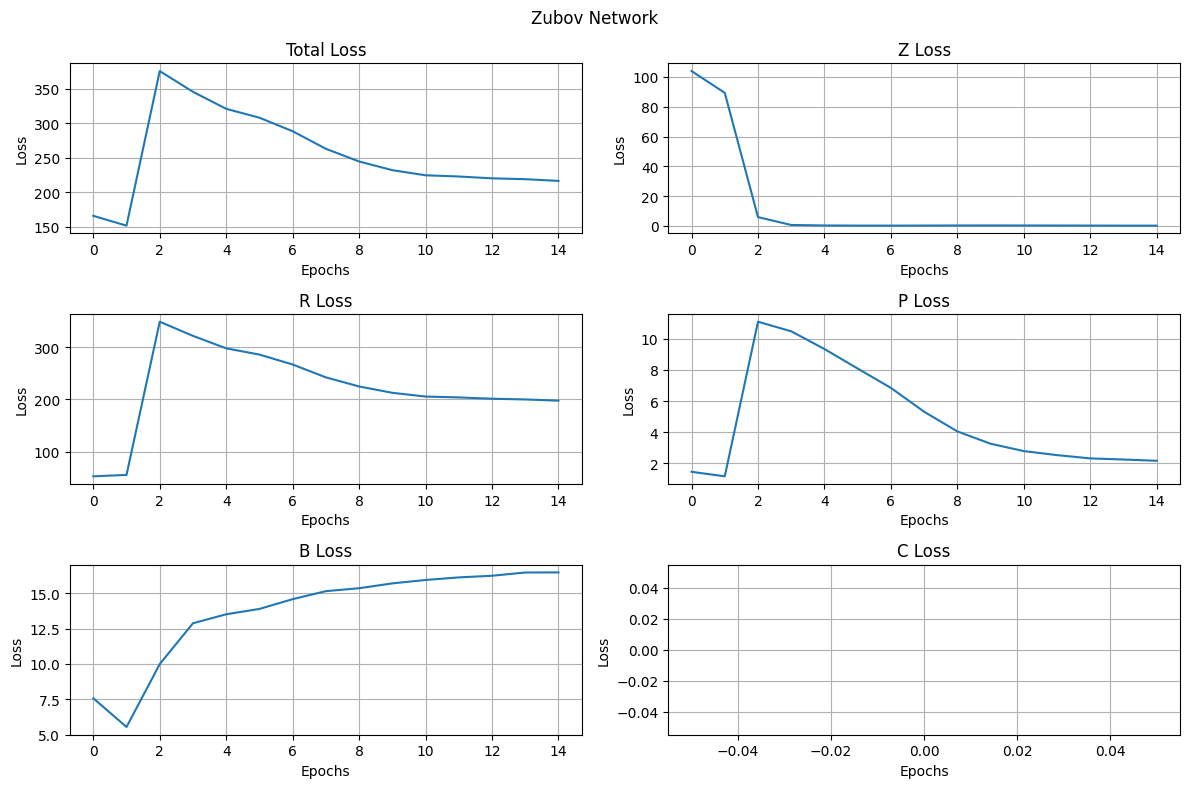

In [16]:
# train the Zubov network (only the Zubov function, not the controller)
epochs = 15
fold = 3
stop_barrier_iter = 500
train_arguments = {
    "net": zubov_network,
    "zubov_dataset": zubov_dataset,
    "train_loader": train_loader,
    "epochs": epochs,
    "fold": fold,
    "stop_barrier_iter": stop_barrier_iter,
    "network_name": 'Zubov Network',
    "visualize": True,
}
zubov_network = train_zubov_framework(**train_arguments)

In [23]:
def plot_zubov_heatmap(fig, ax, net: ZubovNetwork, lb_np: ndarray, ub_np: ndarray, threshold: float, dim_samples: int,
                       x_lim: Tuple[float, float], y_lim: Tuple[float, float], title: str):
    """

    :param fig:
    :param ax:
    :param net:
    :param lb_np:
    :param ub_np:
    :param threshold:
    :param dim_samples:
    :param x_lim:
    :param y_lim:
    :param title:
    :return:
    """
    # Sample the Zubov network and plot it. Note that we cannot consider this to be a valid Zubov function until the network
    # gets passed to a verifier. This cell is to simply get a visualization of its output.
    x_lin = np.linspace(lb_np[0], ub_np[0], num=dim_samples)
    y_lin = np.linspace(lb_np[1], ub_np[1], num=dim_samples)
    X, Y = np.meshgrid(x_lin, y_lin)
    # X and Y are shape (dim_samples, dim_samples)
    samples_np = np.stack((X.flatten(), Y.flatten()), axis=1)
    # shape (dim_samples**2, 2)
    samples_torch = torch.from_numpy(samples_np).to(**set_t)
    outputs = net.zubov_fn(samples_torch)
    # offset = net.zubov_fn(torch.zeros(1, 2).to(**set_t))
    # outputs = outputs - offset
    # shape (dim_samples**2, 1)
    outputs = outputs.squeeze(1)
    # shape (dim_samples**2,)
    outputs_np = to_numpy(outputs)

    # Assuming outputs_np is already obtained from your network
    outputs_reshaped = outputs_np.reshape(dim_samples, dim_samples)
    outputs_reshaped = np.clip(outputs_reshaped, a_min=0., a_max=None)  # outputs should only be in range [0, 1] after training

    # Mask the regions where output >= threshold
    gray_mask = outputs_reshaped >= threshold

    # Normalize outputs to [0, 1] for the colormap
    # normalized_outputs = np.clip(outputs_reshaped / threshold, 0, 1)
    normalized_outputs = outputs_reshaped

    # Create an RGB image where gray_mask is applied
    colored_output = plt.cm.viridis(normalized_outputs)  # Use viridis colormap for [0, 0.9]
    colored_output[gray_mask] = [0.5, 0.5, 0.5, 1.0]  # Gray color for values ≥ 0.9

    # Now plot random trajectories. These 3 parameters can be adjusted based on the plot of W(x)
    num_traj = 500
    traj_steps = 800
    traj_lb = torch.tensor((x_lim[0], y_lim[0]), **set_t).reshape(1, -1)
    traj_ub = torch.tensor((x_lim[1], y_lim[1]), **set_t).reshape(1, -1)
    traj_range = (traj_ub - traj_lb)
    rand_init = torch.rand((num_traj, 2)).to(**set_t) * traj_range + traj_lb
    traj_torch = pendulum_continuous.forward_trajectory(rand_init, net.controller, traj_steps)
    traj_torch = torch.cat((rand_init.unsqueeze(1), traj_torch), dim=1)
    traj_np = to_numpy(traj_torch) # shape (num_traj, traj_steps, 2)

    for traj in traj_np:
        ax.plot(traj[:, 0], traj[:, 1], color='red', alpha=0.8)
        ax.quiver(traj[:-1, 0], traj[:-1, 1],
                  traj[1:, 0] - traj[:-1, 0], traj[1:, 1] - traj[:-1, 1],
                  angles='xy', scale_units='xy', scale=1, color='red')

    # Plot settings
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    imshow_ret = ax.imshow(colored_output, origin='lower', extent=[lb_np[0], ub_np[0], lb_np[1], ub_np[1]])
    fig.colorbar(imshow_ret, ax=ax, label=r'$W(x)$')

    # Labels and title
    ax.set_title(f"{title}'s W(x) for Inverted Pendulum")
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel(r"$\dot{\theta}$")

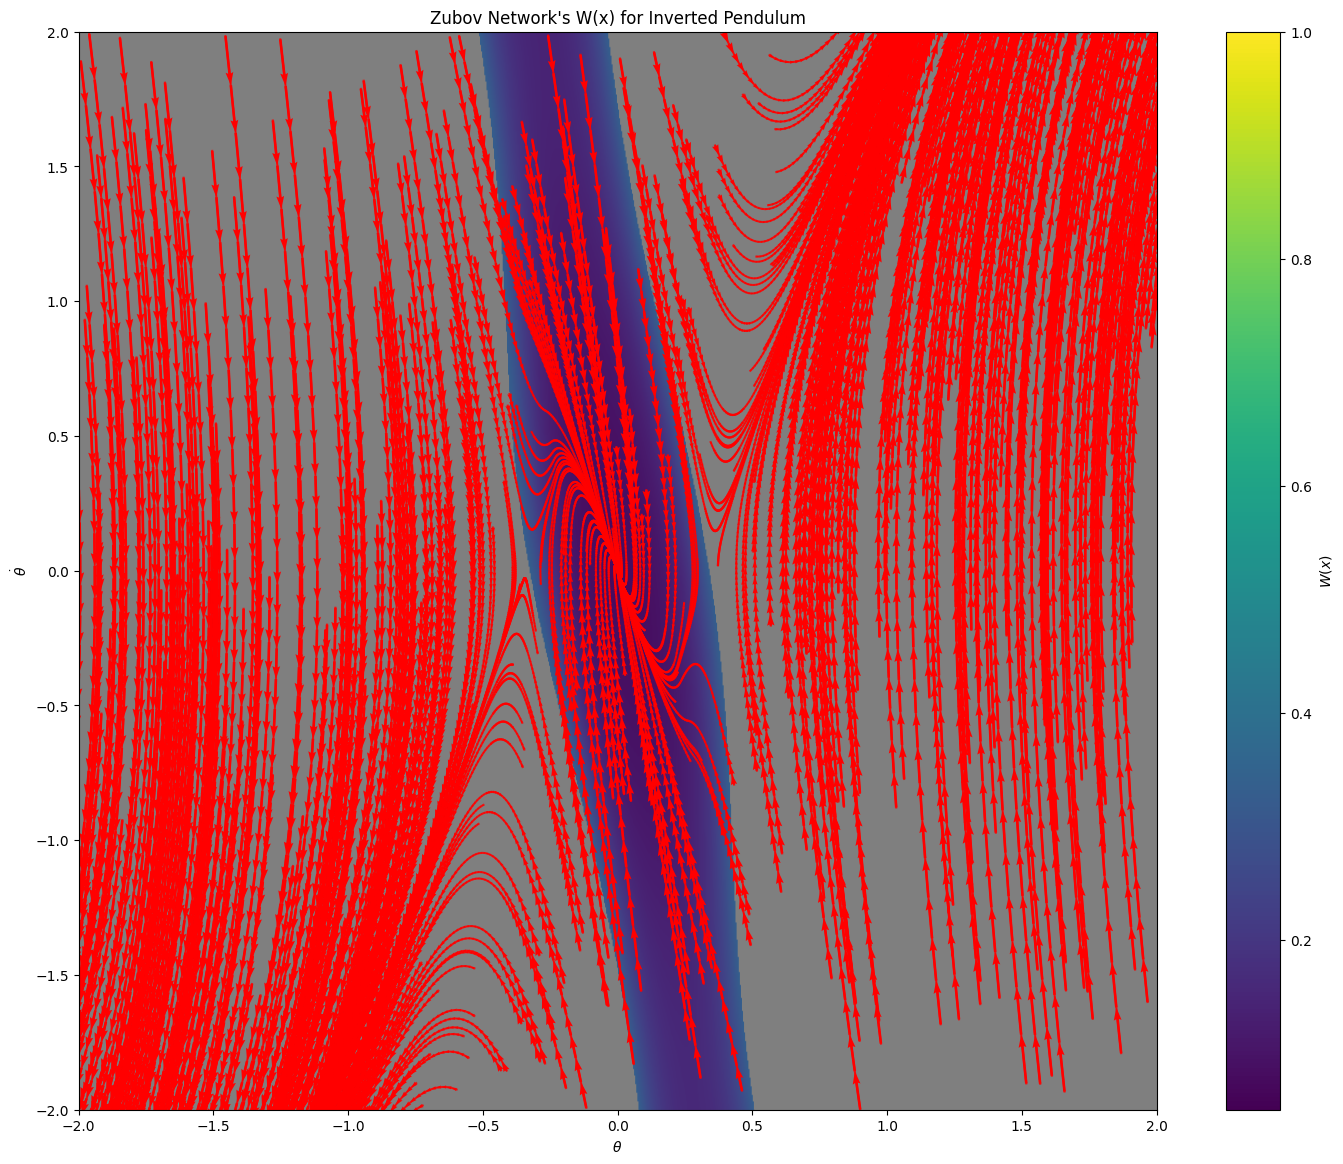

In [18]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(18, 14))
# axs = axs.flatten()

dim_samples = 1000
lb_np = to_numpy(common_args['lb'])
ub_np = to_numpy(common_args['ub'])
x_lim = (-2, 2)
y_lim = (-2, 2)
thresholds = (0.3, .95)
# for ax, net, title, threshold in zip(axs, (zubov_network, zubov_siren_network), ("Zubov Network", "Zubov SIREN Network"), thresholds):
# zubov_network.zubov_fn.final_act = "tanh" # swap final activation to ensure W(x) \in (0, 1)
for ax, net, title, threshold in zip((axs,), (zubov_network,), ("Zubov Network",), (thresholds[0],)):
    plot_zubov_heatmap(fig, ax, net, lb_np, ub_np, threshold, dim_samples, x_lim, y_lim, title)

plt.show()

# Training the Zubov Function and the Controller

In [20]:
# run the training procedure but now include the NN controller
# initialize neural networks
zubov_nn_args = {
    # structure arguments
    "width": 64,
    "n_layers": 3,
    "input_dim": pendulum_continuous.nx,
    "output_dim": 1,
    "act": "tanh",
    "final_act": "sigmoid",
    # training arguments
    "optimizer": torch.optim.Adam,
    "optimizer_parameters": {
        "lr": 1e-3,
        "weight_decay": 1e-5,
    },
    "learning_rate_scheduler": "step",
    "learning_rate_parameters": {
        "step_size": 25,
        "gamma": 0.1,
        "final_lrate": 8e-4,
    },
}
zubov_nn = GeneralNeuralNetwork(**zubov_nn_args)

train_controller = True
if train_controller:
    controller_nn_args = {
        "width": 32,
        "n_layers": 3,
        "input_dim": pendulum_continuous.nx,
        "output_dim": pendulum_continuous.nu,
        "act": "tanh",
        "final_act": "tanh",
        "output_scalar": mgl_3,
        # training_arguments
        "optimizer": torch.optim.Adam,
        "optimizer_parameters": {
            "lr": 1e-1,
            "weight_decay": 1e-5,
        },
        "learning_rate_scheduler": "step",
        "learning_rate_parameters": {
            "step_size": 25,
            "gamma": 0.1,
            "final_lrate": 8e-4,
        },
    }
    zubov_controller = GeneralNeuralNetwork(**controller_nn_args).to(**set_t)
else:
    zubov_controller = lqr_controller

# initialize the networks
common_args = {
    "dynamical_system": pendulum_continuous,
    "zubov_fn": zubov_nn.to(**set_t),
    "controller": zubov_controller,
    "lb": -4*torch.ones_like(pendulum_continuous.x_equilibrium).cpu(),
    # "lb": torch.tensor([-2., -4.], dtype=set_t["dtype"], device=torch.device("cpu")),
    "ub": 4*torch.ones_like(pendulum_continuous.x_equilibrium).cpu(),
    # "ub": torch.tensor([2., 4.], dtype=set_t["dtype"], device=torch.device("cpu")),
    "num_epochs": 500,
}
zubov_args = {
    "train_controller": train_controller,
    "alpha": 0.05,
    "barrier_scale": 1.,
    "max_steps": int(5e3),
    # "c1": 1e3, "c2": 2e3, "c3": 1e3, "c4": 0,
    "c1": 5e1, "c2": 3e3, "c3": 1e2, "c4": 1e1, "c5": 1e2,
}
zubov_args.update(common_args)
zubov_network = ZubovNetwork(**zubov_args)

# initialize the training dataset
batch_size = 2048
use_advance_trajectories = True
adv_traj_dataset = (not train_controller and use_advance_trajectories)
dataset_args = {
    "n_samples": 100_000,
    "lb": common_args["lb"],
    "ub": common_args["ub"],
    "verbose": True, # prints more information when creating the datasets
}
if adv_traj_dataset:
    extra_dataset_args = {
        "dynamical_system": pendulum_continuous,
        "controller_fn": zubov_controller,
        "max_steps": zubov_args["max_steps"],
        "gpu_frac": 0.8,
        "device": set_t["device"],
    }
    dataset_args.update(extra_dataset_args)
# Get the dataset and dataset loader.
# These may be slightly different depending on if the controller is being trained or not.
zubov_dataset, train_loader = get_dataset(advance_trajectories=adv_traj_dataset, batch_size=batch_size,
                                          **dataset_args)

n_samples = 100000, batch_size = 2048
lb shape = torch.Size([1, 2]), ub shape = torch.Size([1, 2])
box_range shape = torch.Size([1, 2])
input_dim = 2


Beginning training of Zubov Network...


Epochs: 100%|██████████| 15/15 [54:53<00:00, 227.13s/it, Epoch loss=615, Loss z=0.000899, Loss r=0.000101, Loss p=9.06e-6, Loss b=0.00213, Loss c=615, lr=0.01, latent lr=None]

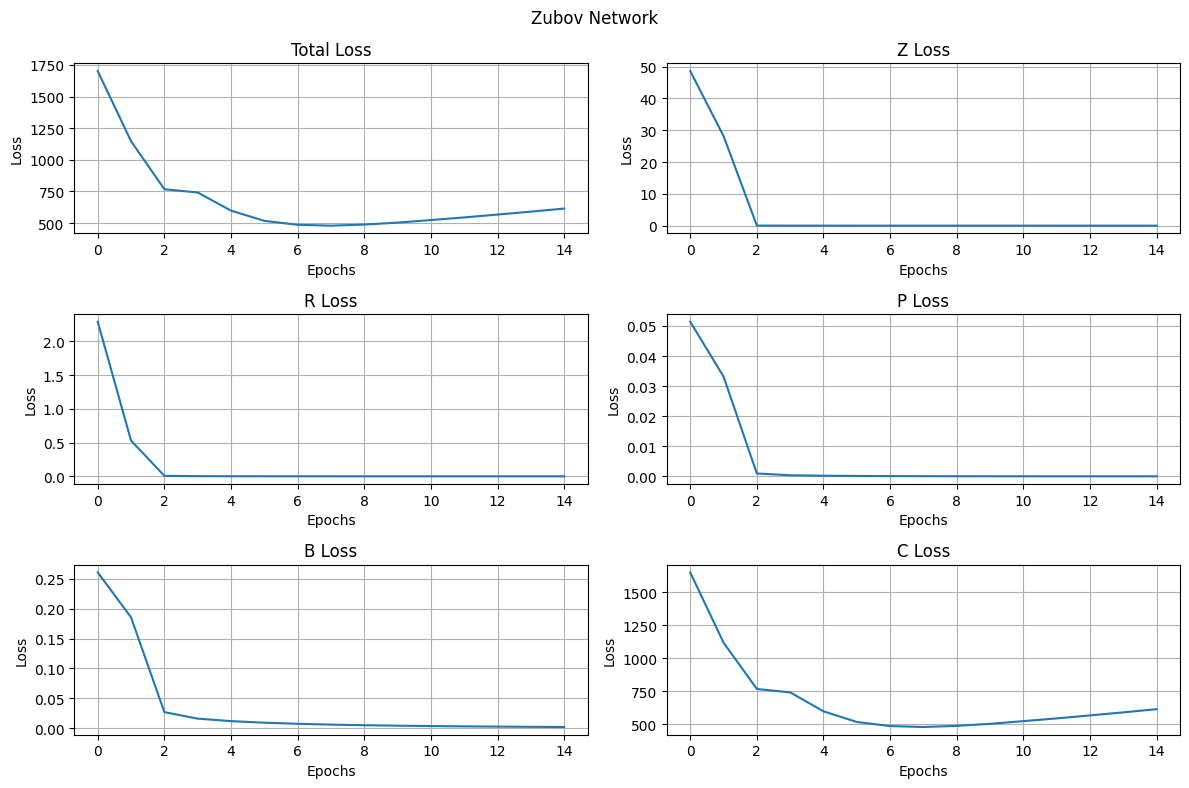

Epochs: 100%|██████████| 15/15 [54:54<00:00, 219.62s/it, Epoch loss=615, Loss z=0.000899, Loss r=0.000101, Loss p=9.06e-6, Loss b=0.00213, Loss c=615, lr=0.01, latent lr=None]


In [21]:
# train the Zubov network (only the Zubov function, with the controller)
epochs = 15
fold = 3
stop_barrier_iter = 500
train_arguments = {
    "net": zubov_network,
    "zubov_dataset": zubov_dataset,
    "train_loader": train_loader,
    "epochs": epochs,
    "fold": fold,
    "stop_barrier_iter": stop_barrier_iter,
    "network_name": 'Zubov Network',
    "visualize": True,
}
zubov_network = train_zubov_framework(**train_arguments)

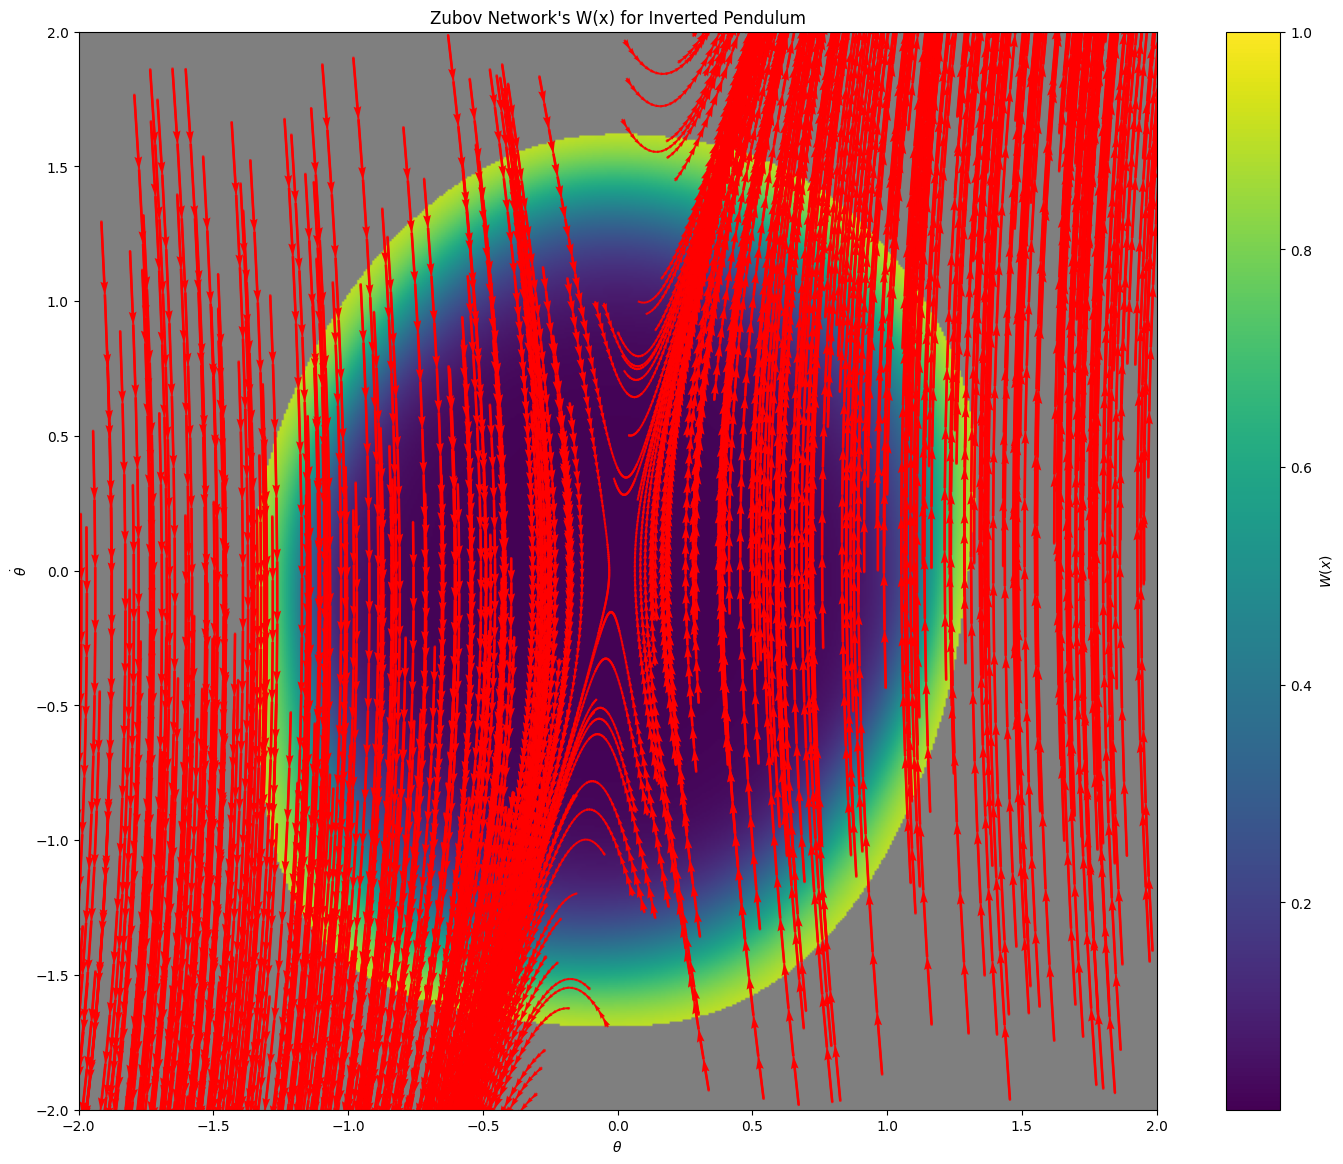

In [25]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(18, 14))
# axs = axs.flatten()

dim_samples = 1000
lb_np = to_numpy(common_args['lb'])
ub_np = to_numpy(common_args['ub'])
x_lim = (-2, 2)
y_lim = (-2, 2)
thresholds = (0.9, .95)
# for ax, net, title, threshold in zip(axs, (zubov_network, zubov_siren_network), ("Zubov Network", "Zubov SIREN Network"), thresholds):
# zubov_network.zubov_fn.final_act = "tanh" # swap final activation to ensure W(x) \in (0, 1)
for ax, net, title, threshold in zip((axs,), (zubov_network,), ("Zubov Network",), (thresholds[0],)):
    plot_zubov_heatmap(fig, ax, net, lb_np, ub_np, threshold, dim_samples, x_lim, y_lim, title)

plt.show()